In [23]:
# Install GSEApy for pathway enrichment analysis.
# Enrichr will be used with Reactome, KEGG, and GO databases.

!pip install -q gseapy

In [24]:
# Import libraries
import gseapy as gp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Mount Google Drive so we can access the DE results
# generated during Step 8.7.

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
# Load the differential-expression results from Step 8.7.

de_df = pd.read_csv(
    "/content/drive/MyDrive/sc-project3-IFN-I/IRC_High_vs_Low_DE.csv"
)

print(de_df.head())
print(f"\nTotal genes in DE table: {len(de_df):,}")

     names      scores  logfoldchanges  pvals  pvals_adj
0  EIF2AK2  146.977330        4.070147    0.0        0.0
1      MX1   87.193130        4.308722    0.0        0.0
2     BST2   62.821815        3.392258    0.0        0.0
3   RNF213   42.278107        0.539485    0.0        0.0
4   EPSTI1   41.953980        1.074664    0.0        0.0

Total genes in DE table: 31,054


In [5]:
# Select genes significantly upregulated in the IRC-High group.
#
# Criteria:
#   log2 fold change > 0.5
#   adjusted p-value < 0.05
#
# The top 100 genes will be used for pathway enrichment.

sig_genes = de_df[
    (de_df["logfoldchanges"] > 0.5) &
    (de_df["pvals_adj"] < 0.05)
]["names"].tolist()[:100]

print(f"Number of significant genes selected: {len(sig_genes)}")
print("\nFirst 20 genes:")
print(sig_genes[:20])

Number of significant genes selected: 100

First 20 genes:
['EIF2AK2', 'MX1', 'BST2', 'RNF213', 'EPSTI1', 'STAT1', 'XAF1', 'IFI44L', 'PARP14', 'IFI44', 'TYMP', 'AOAH', 'JAK2', 'MX2', 'MYO1F', 'LYST', 'SLC8A1', 'NEAT1', 'FCN1', 'DMXL2']


In [6]:
# Perform pathway enrichment using Enrichr.
#
# Three pathway databases are examined:
#   - Reactome
#   - KEGG
#   - GO Biological Process

if len(sig_genes) > 0:

    enr = gp.enrichr(
        gene_list=sig_genes,
        gene_sets=[
            "Reactome_2022",
            "KEGG_2021_Human",
            "GO_Biological_Process_2023"
        ],
        organism="human",
        outdir=None
    )

    print("Pathway enrichment completed.")

else:
    print("No genes passed the significance thresholds.")

Pathway enrichment completed.


In [ ]:
# Save the complete pathway-enrichment results
# so they can be reused for further analysis or plotting.

enr.results.to_csv(
    "/content/drive/MyDrive/sc-project3-IFN-I/pathway_enrichment_results.csv",
    index=False
)

print("Pathway enrichment results saved.")

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

de_df = pd.read_csv(
    "/content/drive/MyDrive/sc-project3-IFN-I/IRC_High_vs_Low_DE.csv"
)

print("DE results:", de_df.shape)
print(de_df.columns.tolist())

DE results: (31054, 5)
['names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj']


In [16]:
# Calculate -log10 adjusted p-value
de_df["-log10_padj"] = -np.log10(
    de_df["pvals_adj"].clip(lower=1e-300)
)

# Define significance
de_df["significant"] = (
    (de_df["pvals_adj"] < 0.05) &
    (abs(de_df["logfoldchanges"]) > 0.5)
)

print(
    "Significant genes:",
    de_df["significant"].sum()
)

Significant genes: 597


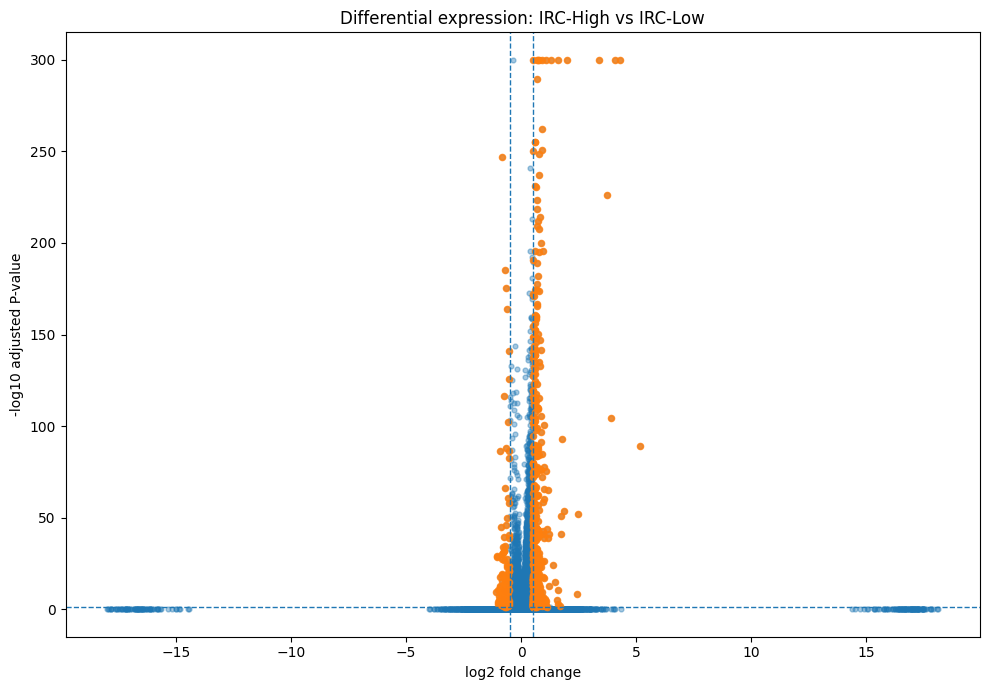

In [17]:
plt.figure(figsize=(10, 7))

# All genes
plt.scatter(
    de_df["logfoldchanges"],
    de_df["-log10_padj"],
    alpha=0.4,
    s=12
)

# Significant genes
sig = de_df[de_df["significant"]]

plt.scatter(
    sig["logfoldchanges"],
    sig["-log10_padj"],
    alpha=0.8,
    s=20
)

# Threshold lines
plt.axvline(
    0.5,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    -0.5,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    -np.log10(0.05),
    linestyle="--",
    linewidth=1
)

plt.xlabel("log2 fold change")
plt.ylabel("-log10 adjusted P-value")
plt.title("Differential expression: IRC-High vs IRC-Low")

plt.tight_layout()
plt.show()

In [26]:
!pip install -q adjustText

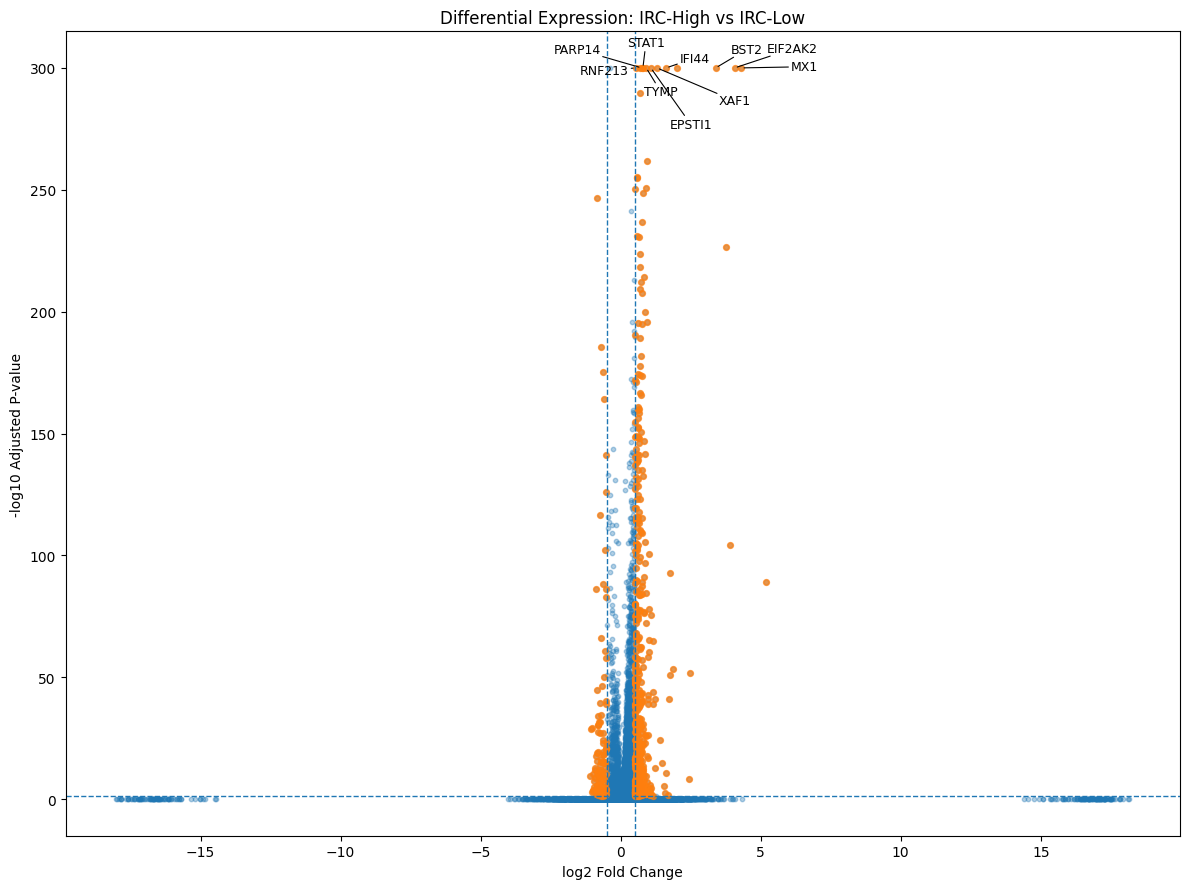

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Calculate -log10 adjusted p-value
de_df["-log10_padj"] = -np.log10(
    de_df["pvals_adj"].clip(lower=1e-300)
)

# Define significant genes
de_df["significant"] = (
    (de_df["pvals_adj"] < 0.05) &
    (abs(de_df["logfoldchanges"]) > 0.5)
)

# Select the 10 most significant genes
top_genes = (
    de_df[
        de_df["significant"]
    ]
    .sort_values("pvals_adj")
    .head(10)
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 9))

# Plot all genes
ax.scatter(
    de_df["logfoldchanges"],
    de_df["-log10_padj"],
    s=10,
    alpha=0.35
)

# Highlight significant genes
sig = de_df[de_df["significant"]]

ax.scatter(
    sig["logfoldchanges"],
    sig["-log10_padj"],
    s=18,
    alpha=0.7
)

# Create text labels
texts = []

for _, row in top_genes.iterrows():

    text = ax.text(
        row["logfoldchanges"],
        row["-log10_padj"],
        row["names"],
        fontsize=9
    )

    texts.append(text)

# Automatically separate labels
adjust_text(
    texts,
    ax=ax,

    # Push labels away from each other
    force_text=(1.5, 2.0),

    # Push labels away from the data points
    force_static=(1.0, 1.0),

    # Allow labels to move vertically and horizontally
    only_move={
        "text": "xy",
        "static": "xy",
        "explode": "xy",
        "pull": "xy"
    },

    # Draw arrows from labels to their genes
    arrowprops=dict(
        arrowstyle="-",
        linewidth=0.8
    )
)

# Significance thresholds
ax.axvline(
    0.5,
    linestyle="--",
    linewidth=1
)

ax.axvline(
    -0.5,
    linestyle="--",
    linewidth=1
)

ax.axhline(
    -np.log10(0.05),
    linestyle="--",
    linewidth=1
)

# Axis labels
ax.set_xlabel("log2 Fold Change")
ax.set_ylabel("-log10 Adjusted P-value")

ax.set_title(
    "Differential Expression: IRC-High vs IRC-Low"
)

plt.tight_layout()
plt.show()

In [19]:
pathway_df = pd.read_csv(
    "/content/drive/MyDrive/sc-project3-IFN-I/pathway_enrichment_results.csv"
)

print("Pathway results:", pathway_df.shape)
print(pathway_df.columns.tolist())

Pathway results: (1769, 10)
['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Old P-value', 'Old Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes']


In [20]:
# Keep the most significant pathways
top_pathways = (
    pathway_df
    .sort_values("Adjusted P-value")
    .head(15)
    .copy()
)

# Calculate -log10 adjusted P-value
top_pathways["-log10_padj"] = -np.log10(
    top_pathways["Adjusted P-value"].clip(lower=1e-300)
)

# Print them for checking
print(
    top_pathways[
        ["Gene_set", "Term", "Adjusted P-value"]
    ].to_string(index=False)
)

                  Gene_set                                                    Term  Adjusted P-value
GO_Biological_Process_2023                  Defense Response To Virus (GO:0051607)      3.622236e-10
GO_Biological_Process_2023               Defense Response To Symbiont (GO:0140546)      3.622236e-10
             Reactome_2022                              Immune System R-HSA-168256      4.020870e-10
GO_Biological_Process_2023                       Response To Cytokine (GO:0034097)      5.458075e-10
             Reactome_2022       Cytokine Signaling In Immune System R-HSA-1280215      4.673238e-08
             Reactome_2022            Interferon Alpha/Beta Signaling R-HSA-909733      3.557595e-07
             Reactome_2022                       Interferon Signaling R-HSA-913531      4.886755e-07
             Reactome_2022                       Innate Immune System R-HSA-168249      1.293098e-05
GO_Biological_Process_2023        Cytokine-Mediated Signaling Pathway (GO:0019221)      1.9

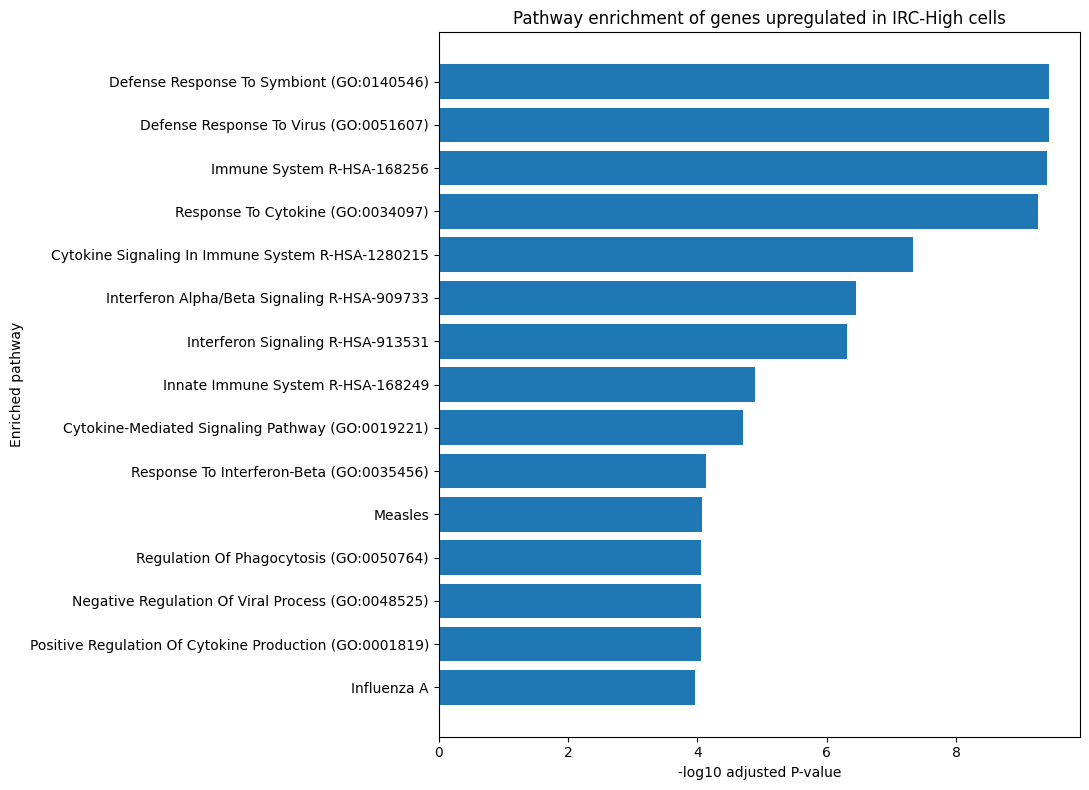

In [21]:
plt.figure(figsize=(11, 8))

plot_df = top_pathways.sort_values(
    "-log10_padj",
    ascending=True
)

plt.barh(
    plot_df["Term"],
    plot_df["-log10_padj"]
)

plt.xlabel("-log10 adjusted P-value")
plt.ylabel("Enriched pathway")
plt.title(
    "Pathway enrichment of genes upregulated in IRC-High cells"
)

plt.tight_layout()
plt.show()